# Inspect the multimodal-survey dataset

Five species-diverse examples: the robot's ground photograph beside its 4 x 4 m
nadir drone crop, with the row's full metadata. Loads the local build in
`out/`; once the private Hugging Face repo is live, the commented line loads
the same thing from the hub.

In [1]:
from datasets import load_from_disk

ds = load_from_disk("out")
# ds = load_dataset("mpg-ranch/multimodal-survey")   # hub equivalent

for split in ds:
    print(f"{split:14s} {ds[split].num_rows:5d} rows")
print(f"\ncolumns ({len(ds['train'].column_names)}):", ", ".join(ds['train'].column_names))
CLASSES = ds["train"].features["species"].feature.names
BANDS = ds["train"].features["artifact_level"].names

/Users/kdoherty/miniforge3/envs/dinov3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train           6480 rows
test            1613 rows
train_tier_2     194 rows

columns (34): frame_id, ground_image, drone_image, species, artifact_level, site, strip, latitude, longitude, altitude_ellipsoidal_m, accuracy_horizontal_m, accuracy_vertical_m, fix_type, pdop, satellites_used, bearing_deg, footprint_wkt, ground_captured_at, drone_captured_at, capture_offset_absolute, capture_offset_time_of_day, capture_event, mission_restart_utc, pair_frame_id, pair_distance_m, pair_overlap_fraction, pair_offset_hours, leg, along_leg_m, frame_offset_s, speed_mps, run_id, tier2_overlap_fraction, drone_coverage


## Pick five examples

One clean frame (`artifact_level` band 1) per target species, spread over five
different species and, where possible, different strips and capture events.
Selection is deterministic.

In [2]:
TARGETS = ["Lupinus sericeus", "Balsamorhiza sagittata", "Gaillardia aristata",
           "Euphorbia virgata", "Bromus tectorum"]

train = ds["train"].remove_columns(["ground_image", "drone_image"])[:]
picks, used = [], set()
for name in TARGETS:
    sid = CLASSES.index(name)
    best = None
    for i in range(len(train["frame_id"])):
        if sid not in train["species"][i] or train["artifact_level"][i] != 0:
            continue
        key = (train["site"][i], train["strip"][i], train["capture_event"][i])
        score = (key in used, len(train["species"][i]))   # prefer new strip, fewer co-occurring species
        if best is None or score < best[0]:
            best = (score, i, key)
    picks.append(best[1]); used.add(best[2])

for name, i in zip(TARGETS, picks):
    print(f"{name:24s} -> {train['frame_id'][i]}  ({train['site'][i]}/{train['strip'][i]}, "
          f"event {train['capture_event'][i]})")

Lupinus sericeus         -> leg03_m073_b203_2026-06-16T16-17-17  (site_1/strip_1, event 1)
Balsamorhiza sagittata   -> leg05_m030_b023_2026-06-18T16-15-56  (site_1/strip_1, event 2)
Gaillardia aristata      -> leg03_m097_b182_2026-06-16T10-33-31  (site_1/strip_4, event 1)
Euphorbia virgata        -> leg03_m008_b149_2026-06-17T10-38-29  (site_2/strip_1, event 1)
Bromus tectorum          -> leg03_m071_b195_2026-06-16T15-10-43  (site_1/strip_2, event 1)


## The pairs, with metadata

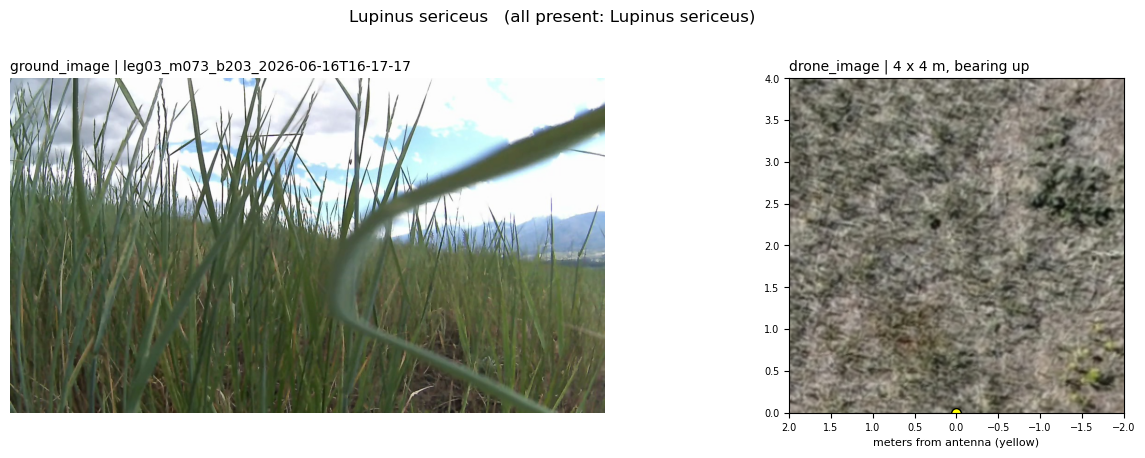

frame_id                                                                                                                          leg03_m073_b203_2026-06-16T16-17-17
species                                                                                                                                            [Lupinus sericeus]
artifact_level                                                                                                                                                  0-25%
site                                                                                                                                                           site_1
strip                                                                                                                                                         strip_1
latitude                                                                                                                                                    46.675823
long

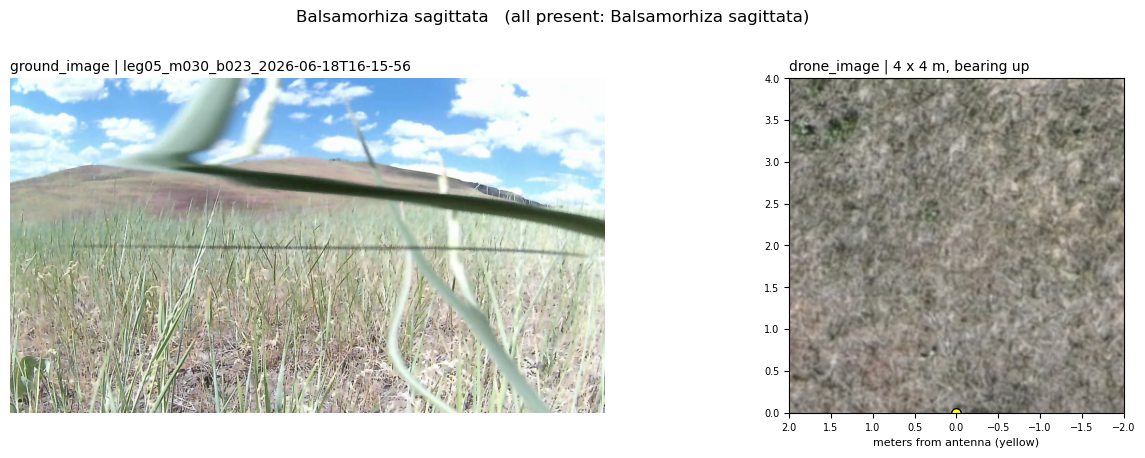

frame_id                                                                                                                          leg05_m030_b023_2026-06-18T16-15-56
species                                                                                                                                      [Balsamorhiza sagittata]
artifact_level                                                                                                                                                  0-25%
site                                                                                                                                                           site_1
strip                                                                                                                                                         strip_1
latitude                                                                                                                                                      46.6756
long

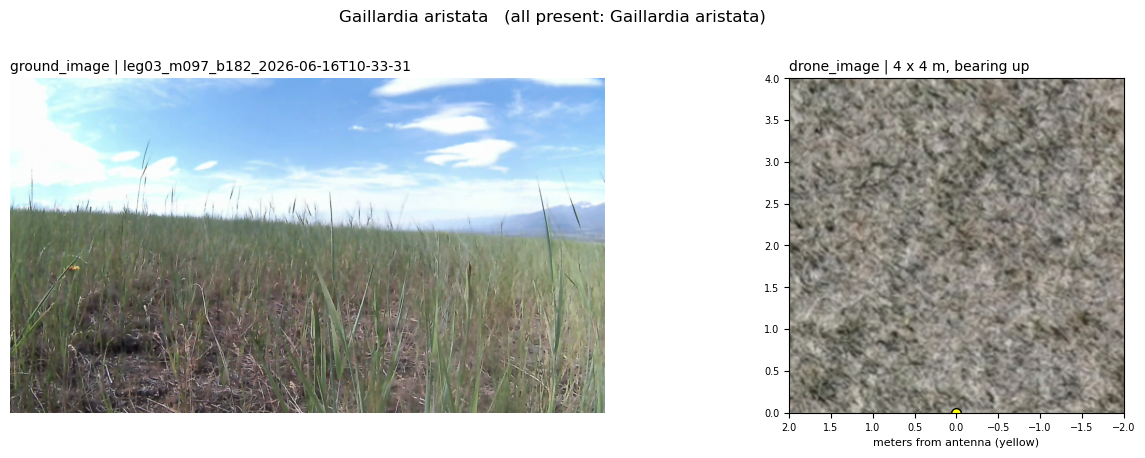

frame_id                                                                                                                          leg03_m097_b182_2026-06-16T10-33-31
species                                                                                                                                         [Gaillardia aristata]
artifact_level                                                                                                                                                  0-25%
site                                                                                                                                                           site_1
strip                                                                                                                                                         strip_4
latitude                                                                                                                                                    46.675573
long

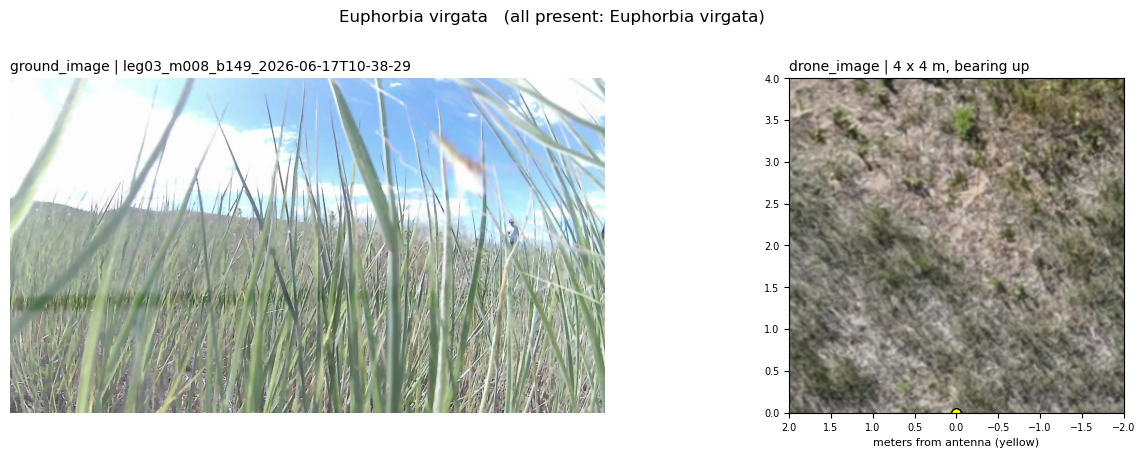

frame_id                                                                                                                          leg03_m008_b149_2026-06-17T10-38-29
species                                                                                                                                           [Euphorbia virgata]
artifact_level                                                                                                                                                  0-25%
site                                                                                                                                                           site_2
strip                                                                                                                                                         strip_1
latitude                                                                                                                                                    46.697274
long

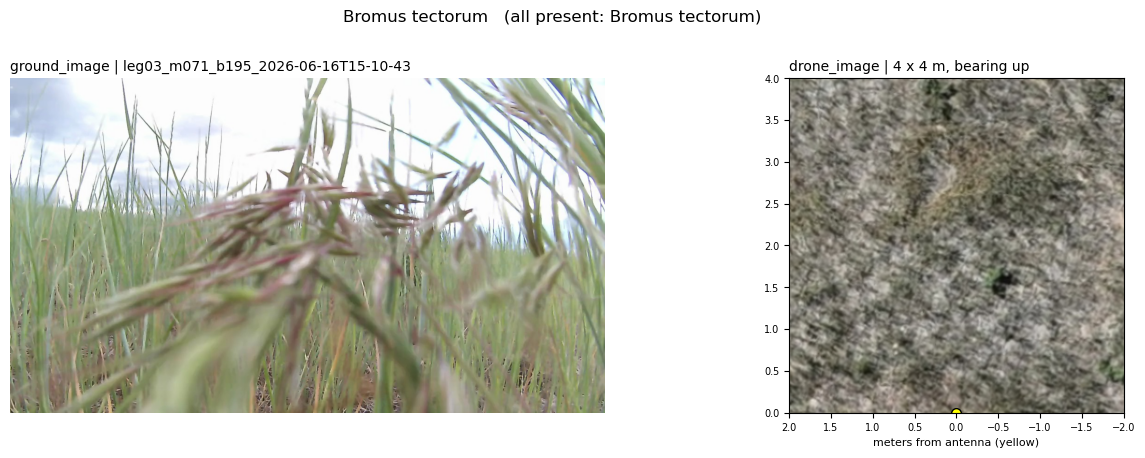

frame_id                                                                                                                          leg03_m071_b195_2026-06-16T15-10-43
species                                                                                                                                             [Bromus tectorum]
artifact_level                                                                                                                                                  0-25%
site                                                                                                                                                           site_1
strip                                                                                                                                                         strip_2
latitude                                                                                                                                                    46.675715
long

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 200)

for name, i in zip(TARGETS, picks):
    row = ds["train"][i]
    species_names = [CLASSES[s] for s in row["species"]]

    fig, (ax_g, ax_d) = plt.subplots(1, 2, figsize=(13, 4.4),
                                     gridspec_kw={"width_ratios": [16/9, 1]})
    ax_g.imshow(row["ground_image"])
    ax_g.set_title(f"ground_image | {row['frame_id']}", fontsize=10, loc="left")
    ax_g.axis("off")

    ax_d.imshow(row["drone_image"], extent=[2, -2, 0, 4], origin="upper")
    ax_d.plot(0, 0, "o", ms=7, mfc="yellow", mec="black")
    ax_d.set_title("drone_image | 4 x 4 m, bearing up", fontsize=10, loc="left")
    ax_d.set_xlabel("meters from antenna (yellow)", fontsize=8)
    ax_d.tick_params(labelsize=7)
    fig.suptitle(f"{name}   (all present: {', '.join(species_names)})",
                 fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    meta = {k: v for k, v in row.items() if k not in ("ground_image", "drone_image")}
    meta["species"] = species_names
    meta["artifact_level"] = BANDS[meta["artifact_level"]]
    print(pd.Series(meta).to_string(), "\n")

The drone panel uses the crop's own coordinate frame: the yellow dot is the
GNSS antenna, up is the robot's bearing, and one pixel is 1.28 cm. See the
dataset card for re-cropping and geometry recipes.